## 2. Histogram-based Outlier Score (HBOS)

In [1]:
#!pip install pyod
#!pip install combo
#!pip install numpy pandas

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

Matplotlib is building the font cache; this may take a moment.


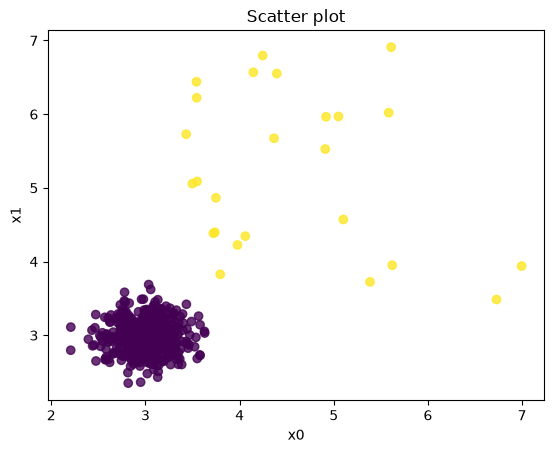

In [6]:
def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [36]:
from pyod.models.hbos import HBOS
n_bins=30
contamination = 0.05
hbos = HBOS(n_bins=n_bins, contamination=contamination)
hbos.fit(X_train)

,n_bins,30
,contamination,0.05
,alpha,0.1
,tol,0.5
Name,Type,Value
bin_edges_,"ndarray[float64](31, 6)","[[2.21,2.35,2.33,2.35,2.36,2.28], [2.37,2.5 ,2.48,2.5 ,2.51,2.43], [2.53,2.65,2.64,2.66,2.67,2.59], ..., [6.68,6.61,6.67,6.69,6.64,6.52], [6.84,6.76,6.82,6.84,6.8 ,6.67], [7. ,6.91,6.98,7. ,6.95,6.82]]"
decision_scores_,"ndarray[float64](500,)","[ 1.03, 0.44, 1.2 ,...,15.41,16.56,17.98]"
hist_,"ndarray[float64](30, 6)","[[0.03,0.07,0.12,0.09,0.12,0.03], [0.11,0.29,0.35,0.25,0.43,0.11], [0.34,1.03,0.74,0.84,0.86,0.46], ..., [0. ,0.03,0.01,0.01,0.01,0. ], [0.01,0. ,0. ,0.03,0. ,0.05], [0.01,0.03,0.04,0.03,0.04,0.03]]"
labels_,"ndarray[int64](500,)","[0,0,0,...,1,1,1]"
threshold_,float64,5.574


In [13]:
def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results
    
results = evaluate_model(hbos, X_train, X_test)
y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]
threshold = results["threshold"]

In [26]:
def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , threshold)
print("The training data:", count_stat(y_train_pred))
print("The test data:", count_stat(y_test_pred))

The threshold for the defined contamination rate: 5.574052394139895
The training data: {np.int64(0): np.int64(475), np.int64(1): np.int64(25)}
The test data: {np.int64(0): np.int64(474), np.int64(1): np.int64(26)}


### Step 2: Determine the threshold

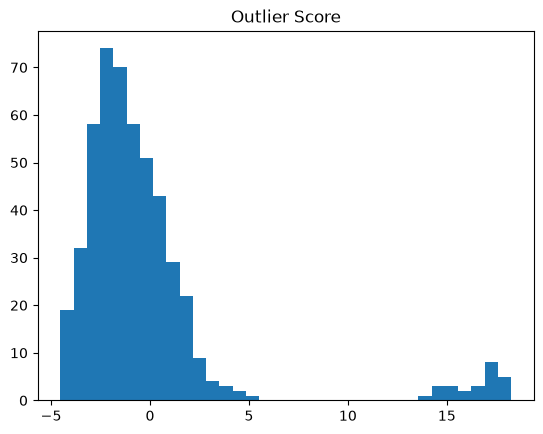

In [27]:
def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [28]:
def descriptive_stats_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

feature_list = ['F1','F2','F3','F4','F4','F5']
descriptive_stat_threshold(X_train,y_train_scores, threshold)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,475,95.0,3.00,2.99,2.99,3.01,2.99,3.02,-1.13
1,Outlier,25,5.0,4.55,5.21,5.47,5.23,5.03,5.06,16.58


In [29]:
descriptive_stat_threshold(X_test,y_test_scores, threshold)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,474,94.8,2.98,2.99,2.99,3.01,2.99,3.00,-1.05
1,Outlier,26,5.2,4.91,5.44,5.13,5.00,4.99,4.82,16.61


In [30]:
def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm
    
confusion_matrix(y_train,y_train_scores,threshold)

Pred,0,1
Actual,,
0.0,475,0
1.0,0,25


In [31]:
confusion_matrix(y_test,y_test_scores,threshold)

Pred,0,1
Actual,,
0.0,474,1
1.0,0,25


### Step 4: Averages

In [47]:
from pyod.utils.utility import standardizer
from pyod.models.combination import average

def hbos_ensemble(
    X_train,
    X_test,
    k_list=[5,10,15,20,25,30,50,60,75,100],
    contamination=0.05):
    """
    Train multiple HBOS detectors with different numbers
    of histogram bins and combine their anomaly scores
    using score averaging.

    Parameters
    ----------
    X_train : ndarray
        Training dataset.

    X_test : ndarray
        Testing dataset.

    k_list : list, default=[5,10,15,20,25,30,50,60,75,100]
        List of n_bins values used to create diverse
        HBOS models.

    contamination : float, default=0.05
        Expected proportion of anomalies in the data.

    Returns
    -------
    dict
        Dictionary containing ensemble anomaly scores
        for the training and testing datasets.
    """

    # Number of HBOS models in the ensemble
    n_clf = len(k_list)

    # Initialize matrices to store anomaly scores
    # from each HBOS detector
    train_scores = np.zeros(
        (X_train.shape[0], n_clf))

    test_scores = np.zeros(
        (X_test.shape[0], n_clf))

    # Train an HBOS model for each bin configuration
    for i, k in enumerate(k_list):
        # Create and train the HBOS detector
        model = HBOS(n_bins=k,contamination=contamination)
        model.fit(X_train)
        
        # Generate anomaly scores on train and test data
        results = evaluate_model(model,
            X_train,
            X_test)

        # Store scores in the ensemble matrices
        train_scores[:, i] = results["train_scores"]
        test_scores[:, i] = results["test_scores"]

    # Standardize scores because different HBOS models
    # may produce scores on different scales
    train_scores_norm, test_scores_norm = standardizer(
        train_scores,
        test_scores)

    # Average normalized training scores across models
    y_train_combined = average(train_scores_norm)

    # Average normalized testing scores across models
    y_test_combined = average(test_scores_norm)

    # Return ensemble scores
    return {
        "train_scores": y_train_combined,
        "test_scores": y_test_combined
    }

In [49]:
results = hbos_ensemble(X_train, X_test)

y_train_combined = results["train_scores"]
y_test_combined  = results["test_scores"]

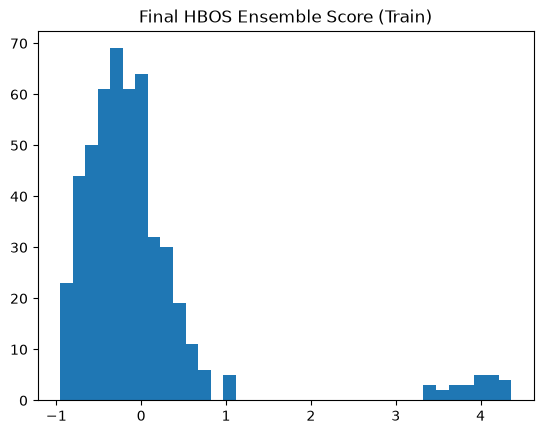

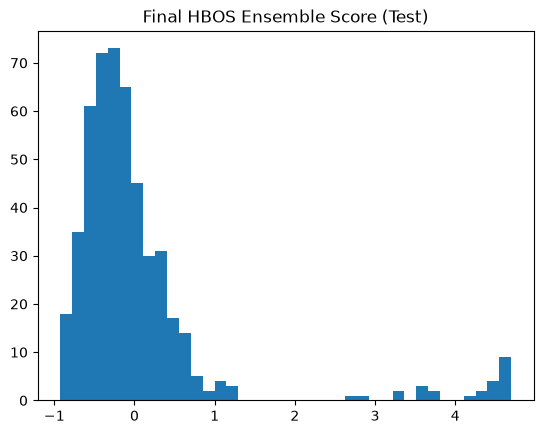

In [54]:
# Plot the histogram of final scores (training data)
plot_hist(y_train_combined, title="Final HBOS Ensemble Score (Train)")

# Optional: plot test scores as well
plot_hist(y_test_combined, title="Final HBOS Ensemble Score (Test)")

In [55]:
descriptive_stat_threshold(X_train,y_train_combined, 1.4)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,475,95.0,3.00,2.99,2.99,3.01,2.99,3.02,-0.21
1,Outlier,25,5.0,4.55,5.21,5.47,5.23,5.03,5.06,3.92


In [56]:
descriptive_stat_threshold(X_test,y_train_combined, 1.4)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,475,95.0,2.98,2.99,2.99,3.01,2.99,3.00,-0.21
1,Outlier,25,5.0,5.00,5.54,5.23,5.05,5.06,4.88,3.92
